# Kruger National Park - Poaching Risk Assessment
## Multimodal Geospatial Analysis & Machine Learning Dataset

This notebook processes satellite imagery, geospatial data, and environmental features to create a comprehensive poaching risk dataset for Kruger National Park.

In [7]:
pip install ee geemap geopandas rasterio pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\arpit\churn-env\Scripts\python.exe -m pip install --upgrade pip


## 1. Setup & Installation
Install required libraries for geospatial analysis, satellite data processing, and machine learning.

In [8]:
import ee
import geemap
ee.Authenticate()
ee.Initialize()

## 2. Authentication & Initialization
Authenticate with Google Earth Engine and initialize geospatial libraries.

In [9]:
import geopandas as gpd

# Make sure you use raw string (r'...') or double backslashes
kruger = gpd.read_file(r'C:\Users\arpit\Jupyter Notebook\New folder\WDPA_WDOECM_Dec2025_Public_873_shp-polygons.shp')

# Convert to WGS84
kruger = kruger.to_crs(epsg=4326)

# Optional: check the first rows
print(kruger.head())


   SITE_ID SITE_PID SITE_TYPE              NAME_ENG                  NAME  \
0      873      873        PA  Kruger National Park  Kruger National Park   

           DESIG      DESIG_ENG DESIG_TYPE      IUCN_CAT        INT_CRIT  ...  \
0  National Park  National Park   National  Not Reported  Not Applicable  ...   

      MANG_PLAN           VERIF  METADATAID  PRNT_ISO3  ISO3       SUPP_INFO  \
0  Not Reported  State Verified        1840        ZAF   ZAF  Not Applicable   

         CONS_OBJ    INLND_WTRS       OECM_ASMT  \
0  Not Applicable  Not Reported  Not Applicable   

                                            geometry  
0  POLYGON ((31.38601 -24.48432, 31.37406 -24.542...  

[1 rows x 34 columns]


## 3. Grid Creation & Geospatial Setup
Load Kruger boundary and create a regular grid overlay for systematic analysis.

In [10]:
import geopandas as gpd
import numpy as np
from shapely.geometry import box

# -------------------------------
# Step 1: Create grid over Kruger
# -------------------------------
minx, miny, maxx, maxy = kruger.total_bounds
dx = dy = 0.018

grid_cells = []
for x0 in np.arange(minx, maxx, dx):
    for y0 in np.arange(miny, maxy, dy):
        x1, y1 = x0 + dx, y0 + dy
        grid_cells.append(box(x0, y0, x1, y1))

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs="EPSG:4326")
grid = gpd.clip(grid, kruger)

# -------------------------------
# Step 2: Reproject to UTM for accurate distance calculations
# -------------------------------
grid_utm = grid.to_crs(epsg=32735)

# Calculate centroid coordinates in meters
grid_utm['centroid_x'] = grid_utm.centroid.x
grid_utm['centroid_y'] = grid_utm.centroid.y

# Add Grid_ID
grid_utm['Grid_ID'] = range(len(grid_utm))

# -------------------------------
# Step 3: Convert back to WGS84 for mapping
# -------------------------------
grid_wgs = grid_utm.to_crs(epsg=4326)
grid_wgs['Lon'] = grid_wgs.centroid.x
grid_wgs['Lat'] = grid_wgs.centroid.y

# -------------------------------
# Step 4: Save to file
# -------------------------------
# Drop any extra geometry columns (none now, safe)
#grid_wgs.to_file('kruger_grid.geojson', driver='GeoJSON')
#grid_wgs.drop(columns='geometry').to_csv('kruger_grid.csv', index=False)

# -------------------------------
# Step 5: Check result
# -------------------------------
print(grid_wgs.head())
print(f"Total grid cells: {len(grid_wgs)}")


                                               geometry     centroid_x  \
3223  POLYGON ((31.23182 -25.1703, 31.23182 -25.1772...  926653.677990   
3922  MULTIPOLYGON (((31.30382 -25.41832, 31.30355 -...  933002.840900   
3923  POLYGON ((31.30382 -25.3863, 31.30382 -25.4043...  932822.230059   
3924  POLYGON ((31.30382 -25.3683, 31.30382 -25.3863...  932716.575061   
3925  POLYGON ((31.28582 -25.3503, 31.30382 -25.3503...  932399.034603   

        centroid_y  Grid_ID        Lon        Lat  
3223  7.209230e+06        0  31.231535 -25.172611  
3922  7.182154e+06        1  31.302980 -25.414621  
3923  7.184560e+06        2  31.300420 -25.393004  
3924  7.186341e+06        3  31.298803 -25.377001  
3925  7.188336e+06        4  31.295019 -25.359121  
Total grid cells: 5594


C:\Users\arpit\AppData\Local\Temp\ipykernel_24280\1503205297.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_wgs['Lon'] = grid_wgs.centroid.x
C:\Users\arpit\AppData\Local\Temp\ipykernel_24280\1503205297.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_wgs['Lat'] = grid_wgs.centroid.y


In [11]:
grid_wgs.to_file('kruger_grid.geojson', driver='GeoJSON')
grid_wgs.drop(columns='geometry').to_csv('kruger_grid.csv', index=False)

In [12]:
import geopandas as gpd

grid = gpd.read_file('kruger_grid.geojson')

In [13]:

def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = row['geometry']
        
        if geom.type == 'Polygon':
            coords = [list(geom.exterior.coords)]
            ee_geom = ee.Geometry.Polygon(coords)
        elif geom.type == 'MultiPolygon':
            coords = [list(p.exterior.coords) for p in geom.geoms]
            ee_geom = ee.Geometry.MultiPolygon(coords)
        else:
            continue
        
        features.append(ee.Feature(ee_geom, {'Grid_ID': row['Grid_ID']}))
    
    return ee.FeatureCollection(features)

grid_fc = gdf_to_ee(grid_wgs)


C:\Users\arpit\AppData\Local\Temp\ipykernel_24280\1465715830.py:6: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\arpit\AppData\Local\Temp\ipykernel_24280\1465715830.py:9: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':


In [14]:
# Sentinel-2 median composite
s2 = (ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
      .filterBounds(grid_fc)
      .filterDate('2024-01-01', '2024-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .median())

# NDVI
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Reduce NDVI per grid cell (mean)
def add_ndvi(feature):
    mean_ndvi = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=10
    )
    return feature.set({'NDVI': mean_ndvi.get('NDVI')})

grid_ndvi_fc = grid_fc.map(add_ndvi)



## 4. Satellite Data Processing
Extract and process Sentinel-2 satellite imagery, compute vegetation indices and environmental features.

In [15]:
import ee

# Authenticate with full scopes (Drive export + Earth Engine)
ee.Authenticate(scopes=[
    'https://www.googleapis.com/auth/earthengine',
    'https://www.googleapis.com/auth/drive',
    'https://www.googleapis.com/auth/devstorage.full_control',
    'https://www.googleapis.com/auth/cloud-platform'
])

ee.Initialize()


In [17]:
import geopandas as gpd

gdf = gpd.read_file('kruger_grid.geojson')
gdf.to_file('kruger_grid.shp')  # creates .shp, .shx, .dbf, etc.


In [23]:
import geopandas as gpd
import pandas as pd
import glob

files = glob.glob(r"C:\Users\arpit\Downloads\grid_ndvi_batch_*.geojson")
print("Found files:", files)

gdfs = [gpd.read_file(f) for f in files]
grid_ndvi = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))


Found files: ['C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_0.geojson', 'C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_1.geojson', 'C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_2.geojson', 'C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_3.geojson', 'C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_4.geojson', 'C:\\Users\\arpit\\Downloads\\grid_ndvi_batch_5.geojson']


In [24]:
import geopandas as gpd
import pandas as pd
import glob

files = glob.glob(r"C:\Users\arpit\Downloads\grid_ndvi_batch_*.geojson")

gdfs = [gpd.read_file(f) for f in files]

# Concatenate and keep CRS
grid_ndvi = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

grid_ndvi


,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,mean,geometry
0,00000000000000000ae9,2793,-22.709387,30.899736,9.007200e+05,7.483380e+06,0.371845,"POLYGON ((30.90782 -22.71541, 30.90782 -22.704..."
1,00000000000000000aeb,2795,-22.699908,30.903580,9.011431e+05,7.484421e+06,0.349758,"MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -..."
2,000000000000000009e8,2536,-23.071500,30.904667,9.001613e+05,7.443216e+06,0.275776,"POLYGON ((30.89942 -23.06684, 30.90196 -23.073..."
3,00000000000000000aed,2797,-22.682878,30.905124,9.013516e+05,7.486305e+06,0.401846,"POLYGON ((30.90159 -22.68471, 30.90174 -22.685..."
4,000000000000000009ea,2538,-23.057077,30.905143,9.002529e+05,7.444814e+06,0.255118,"POLYGON ((30.90782 -23.0643, 30.90782 -23.0463..."
...,...,...,...,...,...,...,...,...
5589,00000000000000000fb4,4020,-25.125349,32.027504,1.007227e+06,7.211707e+06,0.373493,"POLYGON ((32.03131 -25.1343, 32.03106 -25.1163..."
5590,00000000000000000f24,3876,-25.197115,32.027546,1.006933e+06,7.203741e+06,0.303794,"POLYGON ((32.03081 -25.20629, 32.03172 -25.188..."
5591,00000000000000000fb3,4019,-25.143347,32.027633,1.007165e+06,7.209709e+06,0.347351,"POLYGON ((32.03157 -25.1523, 32.03131 -25.1343..."
5592,00000000000000000fb2,4018,-25.161346,32.027761,1.007104e+06,7.207710e+06,0.298461,"POLYGON ((32.03183 -25.1703, 32.03157 -25.1523..."


In [25]:
import geopandas as gpd
import glob

# Path to your downloaded batches
files = glob.glob(r"C:\Users\arpit\Downloads\grid_ndvi_batch_*.geojson")


# Read and concatenate all batches
gdf_list = [gpd.read_file(f) for f in files]
full_grid_ndvi = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))

# Save the full dataset
full_grid_ndvi.to_file("kruger_grid_ndvi_full.geojson", driver="GeoJSON")


In [3]:

import geopandas as gpd

# Load the downloaded file
grid_ndvi = gpd.read_file("kruger_grid_ndvi_full.geojson")

# Quick look at the data
print(grid_ndvi.head())
print(grid_ndvi.columns)



                     id  Grid_ID        Lat        Lon     centroid_x  \
0  00000000000000000ae9     2793 -22.709387  30.899736  900720.039864   
1  00000000000000000aeb     2795 -22.699908  30.903580  901143.133100   
2  000000000000000009e8     2536 -23.071500  30.904667  900161.266125   
3  00000000000000000aed     2797 -22.682878  30.905124  901351.616468   
4  000000000000000009ea     2538 -23.057077  30.905143  900252.857366   

     centroid_y      mean                                           geometry  
0  7.483380e+06  0.371845  POLYGON ((30.90782 -22.71541, 30.90782 -22.704...  
1  7.484421e+06  0.349758  MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...  
2  7.443216e+06  0.275776  POLYGON ((30.89942 -23.06684, 30.90196 -23.073...  
3  7.486305e+06  0.401846  POLYGON ((30.90159 -22.68471, 30.90174 -22.685...  
4  7.444814e+06  0.255118  POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...  
Index(['id', 'Grid_ID', 'Lat', 'Lon', 'centroid_x', 'centroid_y', 'mean',
       'geome

In [34]:
# Example in Python with pandas
import pandas as pd
import numpy as np

df = gpd.read_file("kruger_grid_ndvi_full.geojson")  # your downloaded file

# Rename column
df.rename(columns={'mean':'NDVI'}, inplace=True)

# Create 3 risk bins based on NDVI
# Assuming lower NDVI = easier access (less vegetation), higher NDVI = more dense habitat
df['poaching_risk'] = pd.cut(df['NDVI'],
                             bins=[-np.inf, 0.3, 0.4, np.inf],
                             labels=['High','Medium','Low'])

# Save updated file
df.to_csv('kruger_grid_risk.csv', index=False)


In [5]:
df

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,poaching_risk
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,"POLYGON ((30.90782 -22.71541, 30.90782 -22.704...",Medium
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,"MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...",Medium
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,"POLYGON ((30.89942 -23.06684, 30.90196 -23.073...",High
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,"POLYGON ((30.90159 -22.68471, 30.90174 -22.685...",Low
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,"POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...",High
...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,"POLYGON ((31.87982 -25.1703, 31.87982 -25.1523...",Medium
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,"POLYGON ((31.87982 -25.1523, 31.87982 -25.1343...",Medium
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,"POLYGON ((31.87982 -25.1163, 31.87982 -25.0983...",Medium
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,"POLYGON ((31.87982 -25.0983, 31.87982 -25.0803...",Medium


In [6]:
import pandas as pd

# Load landcover dataset
land = pd.read_csv("kruger_landcover.csv")

# Merge using the correct key
df = df.merge(
    land[["system:index", "mode"]],
    left_on="id",
    right_on="system:index",
    how="left"
)

# Rename the landcover column
df.rename(columns={"mode": "landcover"}, inplace=True)

# Drop duplicate ID column
df.drop(columns=["system:index"], inplace=True)


In [7]:
df

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,poaching_risk,landcover
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,"POLYGON ((30.90782 -22.71541, 30.90782 -22.704...",Medium,20.0
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,"MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...",Medium,20.0
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,"POLYGON ((30.89942 -23.06684, 30.90196 -23.073...",High,20.0
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,"POLYGON ((30.90159 -22.68471, 30.90174 -22.685...",Low,20.0
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,"POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...",High,20.0
...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,"POLYGON ((31.87982 -25.1703, 31.87982 -25.1523...",Medium,10.0
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,"POLYGON ((31.87982 -25.1523, 31.87982 -25.1343...",Medium,10.0
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,"POLYGON ((31.87982 -25.1163, 31.87982 -25.0983...",Medium,30.0
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,"POLYGON ((31.87982 -25.0983, 31.87982 -25.0803...",Medium,30.0


In [8]:
water = pd.read_csv("kruger_water.csv")
water

,system:index,Grid_ID,Lat,Lon,centroid_x,centroid_y,mean,.geo
0,00000000000000000ae9,2793,-22.709387,30.899736,9.007200e+05,7.483380e+06,41.000000,"{""type"":""Polygon"",""coordinates"":[[[30.90781751..."
1,00000000000000000aeb,2795,-22.699908,30.903580,9.011431e+05,7.484421e+06,29.777358,"{""type"":""MultiPolygon"",""coordinates"":[[[[30.90..."
2,000000000000000009e8,2536,-23.071500,30.904667,9.001613e+05,7.443216e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[30.89942101..."
3,00000000000000000aed,2797,-22.682878,30.905124,9.013516e+05,7.486305e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[30.90159257..."
4,000000000000000009ea,2538,-23.057077,30.905143,9.002529e+05,7.444814e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[30.90781751..."
...,...,...,...,...,...,...,...,...
5589,00000000000000000fb4,4020,-25.125349,32.027504,1.007227e+06,7.211707e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[32.03131475..."
5590,00000000000000000f24,3876,-25.197115,32.027546,1.006933e+06,7.203741e+06,3.555556,"{""type"":""Polygon"",""coordinates"":[[[32.03081085..."
5591,00000000000000000fb3,4019,-25.143347,32.027633,1.007165e+06,7.209709e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[32.03157338..."
5592,00000000000000000fb2,4018,-25.161346,32.027761,1.007104e+06,7.207710e+06,NaN,"{""type"":""Polygon"",""coordinates"":[[[32.03183200..."


In [9]:
print(water.columns)


Index(['system:index', 'Grid_ID', 'Lat', 'Lon', 'centroid_x', 'centroid_y',
       'mean', '.geo'],
      dtype='object')


In [10]:

water_clean = water[['Grid_ID', 'mean']].copy()
water_clean = water_clean.rename(columns={'mean': 'Water'})

# --- MERGE WITH MAIN DF ---
df = df.merge(water_clean, on='Grid_ID', how='left')

# Inspect the merged dataframe
print(df.head())

                     id  Grid_ID        Lat        Lon     centroid_x  \
0  00000000000000000ae9     2793 -22.709387  30.899736  900720.039864   
1  00000000000000000aeb     2795 -22.699908  30.903580  901143.133100   
2  000000000000000009e8     2536 -23.071500  30.904667  900161.266125   
3  00000000000000000aed     2797 -22.682878  30.905124  901351.616468   
4  000000000000000009ea     2538 -23.057077  30.905143  900252.857366   

     centroid_y      NDVI                                           geometry  \
0  7.483380e+06  0.371845  POLYGON ((30.90782 -22.71541, 30.90782 -22.704...   
1  7.484421e+06  0.349758  MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...   
2  7.443216e+06  0.275776  POLYGON ((30.89942 -23.06684, 30.90196 -23.073...   
3  7.486305e+06  0.401846  POLYGON ((30.90159 -22.68471, 30.90174 -22.685...   
4  7.444814e+06  0.255118  POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...   

  poaching_risk  landcover      Water  
0        Medium       20.0  41.000000  


In [11]:
elevations = pd.read_csv("kruger_elevation.csv")

In [12]:
print(elevations)

              system:index  Grid_ID        Lat        Lon    centroid_x  \
0     00000000000000000ae9     2793 -22.709387  30.899736  9.007200e+05   
1     00000000000000000aeb     2795 -22.699908  30.903580  9.011431e+05   
2     000000000000000009e8     2536 -23.071500  30.904667  9.001613e+05   
3     00000000000000000aed     2797 -22.682878  30.905124  9.013516e+05   
4     000000000000000009ea     2538 -23.057077  30.905143  9.002529e+05   
...                    ...      ...        ...        ...           ...   
5589  00000000000000000fb4     4020 -25.125349  32.027504  1.007227e+06   
5590  00000000000000000f24     3876 -25.197115  32.027546  1.006933e+06   
5591  00000000000000000fb3     4019 -25.143347  32.027633  1.007165e+06   
5592  00000000000000000fb2     4018 -25.161346  32.027761  1.007104e+06   
5593  00000000000000000f25     3877 -25.179293  32.027860  1.007039e+06   

        centroid_y        mean  \
0     7.483380e+06  472.206415   
1     7.484421e+06  442.071123 

In [15]:
elevation = elevations[['Grid_ID', 'mean']].copy()
elevation = elevation.rename(columns={'mean': 'elevation'})

# --- MERGE WITH MAIN DF ---
df = df.merge(elevation, on='Grid_ID', how='left')

# Inspect the merged dataframe
print(df.head())

                     id  Grid_ID        Lat        Lon     centroid_x  \
0  00000000000000000ae9     2793 -22.709387  30.899736  900720.039864   
1  00000000000000000aeb     2795 -22.699908  30.903580  901143.133100   
2  000000000000000009e8     2536 -23.071500  30.904667  900161.266125   
3  00000000000000000aed     2797 -22.682878  30.905124  901351.616468   
4  000000000000000009ea     2538 -23.057077  30.905143  900252.857366   

     centroid_y      NDVI                                           geometry  \
0  7.483380e+06  0.371845  POLYGON ((30.90782 -22.71541, 30.90782 -22.704...   
1  7.484421e+06  0.349758  MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...   
2  7.443216e+06  0.275776  POLYGON ((30.89942 -23.06684, 30.90196 -23.073...   
3  7.486305e+06  0.401846  POLYGON ((30.90159 -22.68471, 30.90174 -22.685...   
4  7.444814e+06  0.255118  POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...   

  poaching_risk  landcover      Water   elevation  
0        Medium       20.0  

In [38]:
import pandas as pd
import numpy as np

# First, compute a simple composite risk score
# You can adjust the weights as needed
df['risk_score'] = (
    (1 - df['NDVI']) +                      # lower NDVI → higher risk
    df['Water'].fillna(0)/100 +             # higher water presence → higher risk
    df['dist_to_water'].fillna(5000)/5000 + # closer to water → higher risk
    df['burned_area'].fillna(0) +           # more burned area → higher risk
    (500 - df['elevation'].fillna(500))/500 # lower elevation → higher risk
)

# Normalize risk_score (optional)
df['risk_score'] = (df['risk_score'] - df['risk_score'].min()) / (df['risk_score'].max() - df['risk_score'].min())

# Create categorical poaching risk based on quantiles
df['poaching_risk'] = pd.qcut(df['risk_score'], q=3, labels=['Low','Medium','High'])

# Inspect
print(df[['Grid_ID','NDVI','Water','dist_to_water','burned_area','elevation','risk_score','poaching_risk']].head())


   Grid_ID      NDVI      Water  dist_to_water  burned_area   elevation  \
0     2793  0.371845  41.000000     845.377507     0.423529  472.206415   
1     2795  0.349758  29.777358     437.198946     0.666667  442.071123   
2     2536  0.275776        NaN    4689.884078     0.000000  468.843681   
3     2797  0.401846        NaN     487.156132     0.000000  495.954250   
4     2538  0.255118        NaN    4603.308043     0.000000  470.201273   

   risk_score poaching_risk  
0    0.013092           Low  
1    0.014845           Low  
2    0.013600           Low  
3    0.000000           Low  
4    0.013609           Low  


## 5. Feature Engineering & Risk Scoring
Combine multiple environmental factors to compute poaching risk scores and categorical risk levels.

In [40]:
df.head()

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,poaching_risk,landcover,Water,dist_to_water,burned_area,elevation,risk_score
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,"POLYGON ((30.90782 -22.71541, 30.90782 -22.704...",Low,20.0,41.000000,845.377507,0.423529,472.206415,0.013092
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,"MULTIPOLYGON (((30.90265 -22.68633, 30.90303 -...",Low,20.0,29.777358,437.198946,0.666667,442.071123,0.014845
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,"POLYGON ((30.89942 -23.06684, 30.90196 -23.073...",Low,20.0,NaN,4689.884078,0.000000,468.843681,0.013600
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,"POLYGON ((30.90159 -22.68471, 30.90174 -22.685...",Low,20.0,NaN,487.156132,0.000000,495.954250,0.000000
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,"POLYGON ((30.90782 -23.0643, 30.90782 -23.0463...",Low,20.0,NaN,4603.308043,0.000000,470.201273,0.013609


In [23]:
df.to_csv('final_kruger_poaching_1.csv', index=False)

In [19]:
import numpy as np

# Function to compute poaching risk score
def compute_poaching_risk(row):
    score = 0
    
    # NDVI: lower vegetation → higher accessibility → higher risk
    if row['NDVI'] < 0.3:
        score += 2
    elif row['NDVI'] < 0.4:
        score += 1

    # Landcover: open areas may be easier for poachers
    if row['landcover'] in [10, 20]:  # example: 10=tree cover, 20=grassland
        score += 1

    # Water presence: more water → wildlife concentration → higher risk
    if not np.isnan(row.get('Water', np.nan)):
        if row['Water'] > 50:
            score += 2
        elif row['Water'] > 20:
            score += 1

    # Distance to water: closer → easier poaching
    if not np.isnan(row.get('dist_to_water', np.nan)):
        if row['dist_to_water'] < 500:
            score += 2
        elif row['dist_to_water'] < 1500:
            score += 1

    # Burned areas: recently burned → easier access
    if not np.isnan(row.get('burned_area', np.nan)):
        if row['burned_area'] > 0.5:  # >50% burned
            score += 2
        elif row['burned_area'] > 0.2:
            score += 1

    # Elevation: lowlands easier for poachers
    if not np.isnan(row.get('elevation', np.nan)):
        if row['elevation'] < 500:
            score += 1

    # Assign categorical risk based on total score
    if score >= 6:
        return 'High'
    elif score >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply function to your dataframe
df['poaching_risk_1'] = df.apply(compute_poaching_risk, axis=1)

# Inspect updated dataframe
print(df[['Grid_ID','NDVI','landcover','Water','dist_to_water','burned_area','elevation','poaching_risk_1', 'poaching_risk']].head())


   Grid_ID      NDVI  landcover      Water  dist_to_water  burned_area  \
0     2793  0.371845       20.0  41.000000     845.377507     0.423529   
1     2795  0.349758       20.0  29.777358     437.198946     0.666667   
2     2536  0.275776       20.0        NaN    4689.884078     0.000000   
3     2797  0.401846       20.0        NaN     487.156132     0.000000   
4     2538  0.255118       20.0        NaN    4603.308043     0.000000   

    elevation poaching_risk_1 poaching_risk  
0  472.206415          Medium           Low  
1  442.071123            High           Low  
2  468.843681          Medium           Low  
3  495.954250          Medium           Low  
4  470.201273          Medium           Low  


In [17]:
df = pd.read_csv('final_kruger_poaching.csv')

In [28]:
df


,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,poaching_risk,landcover,Water,dist_to_water,burned_area,elevation,risk_score,poaching_risk_1
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,Low,20.0,41.000000,845.377507,0.423529,472.206415,0.013092,Medium
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,Low,20.0,29.777358,437.198946,0.666667,442.071123,0.014845,High
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,Low,20.0,NaN,4689.884078,0.000000,468.843681,0.013600,Medium
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,Low,20.0,NaN,487.156132,0.000000,495.954250,0.000000,Medium
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,Low,20.0,NaN,4603.308043,0.000000,470.201273,0.013609,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,POLYGON ((31.879821304251173 -25.1702966612392...,Medium,10.0,NaN,5996.506627,0.000000,218.629715,0.023151,Medium
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,POLYGON ((31.879821304251173 -25.1522952486799...,Medium,10.0,NaN,5075.473015,0.000000,220.253500,0.020436,Low
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,POLYGON ((31.879821304251173 -25.1162968719673...,Low,30.0,NaN,1605.434424,0.000000,190.475398,0.012314,Low
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,POLYGON ((31.879821304251173 -25.0982955595823...,Low,30.0,31.679961,502.629840,0.000000,183.341974,0.013580,Medium


In [20]:
df['poaching_risk'].value_counts()


poaching_risk
Low       1698
High      1698
Medium    1698
Name: count, dtype: int64

In [22]:
df.drop(columns=['poaching_risk', 'risk_score'])

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk_1
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,20.0,41.000000,845.377507,0.423529,472.206415,Medium
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,20.0,29.777358,437.198946,0.666667,442.071123,High
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,20.0,NaN,4689.884078,0.000000,468.843681,Medium
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,20.0,NaN,487.156132,0.000000,495.954250,Medium
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,20.0,NaN,4603.308043,0.000000,470.201273,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,POLYGON ((31.879821304251173 -25.1702966612392...,10.0,NaN,5996.506627,0.000000,218.629715,Medium
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,POLYGON ((31.879821304251173 -25.1522952486799...,10.0,NaN,5075.473015,0.000000,220.253500,Low
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,POLYGON ((31.879821304251173 -25.1162968719673...,30.0,NaN,1605.434424,0.000000,190.475398,Low
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,POLYGON ((31.879821304251173 -25.0982955595823...,30.0,31.679961,502.629840,0.000000,183.341974,Medium


In [1]:
import pandas as pd

In [36]:
df = pd.read_csv('final_kruger_poaching_1.csv')

In [37]:
df

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,20.0,41.000000,845.377507,0.423529,472.206415,Medium
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,20.0,29.777358,437.198946,0.666667,442.071123,High
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,20.0,NaN,4689.884078,0.000000,468.843681,Medium
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,20.0,NaN,487.156132,0.000000,495.954250,Medium
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,20.0,NaN,4603.308043,0.000000,470.201273,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,POLYGON ((31.879821304251173 -25.1702966612392...,10.0,NaN,5996.506627,0.000000,218.629715,Medium
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,POLYGON ((31.879821304251173 -25.1522952486799...,10.0,NaN,5075.473015,0.000000,220.253500,Low
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,POLYGON ((31.879821304251173 -25.1162968719673...,30.0,NaN,1605.434424,0.000000,190.475398,Low
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,POLYGON ((31.879821304251173 -25.0982955595823...,30.0,31.679961,502.629840,0.000000,183.341974,Medium


In [9]:
RASTER_PATH = "Kruger_Images/kruger_s2_2024_30m-0000000000-0000000000.tif"


In [17]:
RASTER_PATH_2 = "Kruger_Images/kruger_s2_2024_30m-0000005376-0000000000.tif"


In [21]:
RASTER_PATH_3 = "Kruger_Images/kruger_s2_2024_30m-0000010752-0000000000.tif"


In [6]:
import os
import rasterio
import geopandas as gpd
from rasterio.mask import mask
from shapely import wkt


In [7]:
df["geometry"] = df["geometry"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


In [10]:
with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs

gdf = gdf.to_crs(raster_crs)


In [18]:
with rasterio.open(RASTER_PATH_2) as src:
    raster_crs = src.crs

gdf = gdf.to_crs(raster_crs)


In [22]:
with rasterio.open(RASTER_PATH_3) as src:
    raster_crs = src.crs

gdf = gdf.to_crs(raster_crs)


In [11]:
OUT_DIR = "grid_patches"
os.makedirs(OUT_DIR, exist_ok=True)

with rasterio.open(RASTER_PATH) as src:
    for _, row in gdf.iterrows():
        grid_id = row["Grid_ID"]
        geom = [row.geometry]

        try:
            out_img, out_transform = mask(src, geom, crop=True)
        except ValueError:
            continue  # grid outside raster

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform
        })

        out_path = f"{OUT_DIR}/grid_{grid_id}.tif"

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_img)


## 6. Raster Extraction & Image Patches
Extract satellite image patches for each grid cell and standardize to 128×128 pixel format.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1460.7142857142858].


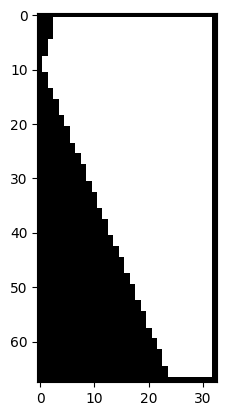

In [19]:
OUT_DIR = "grid_patches_2"
os.makedirs(OUT_DIR, exist_ok=True)

with rasterio.open(RASTER_PATH_2) as src:
    for _, row in gdf.iterrows():
        grid_id = row["Grid_ID"]
        geom = [row.geometry]

        try:
            out_img, out_transform = mask(src, geom, crop=True)
        except ValueError:
            continue  # grid outside raster

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform
        })

        out_path = f"{OUT_DIR}/grid_{grid_id}.tif"

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_img)


In [23]:
OUT_DIR = "grid_patches_3"
os.makedirs(OUT_DIR, exist_ok=True)

with rasterio.open(RASTER_PATH_3) as src:
    for _, row in gdf.iterrows():
        grid_id = row["Grid_ID"]
        geom = [row.geometry]

        try:
            out_img, out_transform = mask(src, geom, crop=True)
        except ValueError:
            continue  # grid outside raster

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform
        })

        out_path = f"{OUT_DIR}/grid_{grid_id}.tif"

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_img)


In [25]:
import os
import shutil

folders = [
    "grid_patches_1",
    "grid_patches_2",
    "grid_patches_3"
]

FINAL_DIR = "grid_patches_final"
os.makedirs(FINAL_DIR, exist_ok=True)

for folder in folders:
    for fname in os.listdir(folder):
        if not fname.endswith(".tif"):
            continue

        dest = os.path.join(FINAL_DIR, fname)

        if not os.path.exists(dest):
            shutil.copy(
                os.path.join(folder, fname),
                dest
            )


In [3]:
import os

img_ids = set(
    int(f.replace("grid_", "").replace(".tif", ""))
    for f in os.listdir("grid_patches_final")
)

df_ids = set(df["Grid_ID"].astype(int))

print("Images:", len(img_ids))
print("DF rows:", len(df_ids))
print("Missing images:", len(df_ids - img_ids))


Images: 5594
DF rows: 5094
Missing images: 0


In [4]:
import rasterio
import numpy as np
import cv2
import os

IN_DIR = "grid_patches_final"
OUT_DIR = "grid_patches_128"
os.makedirs(OUT_DIR, exist_ok=True)

SIZE = 128

for fname in os.listdir(IN_DIR):
    if not fname.endswith(".tif"):
        continue

    with rasterio.open(os.path.join(IN_DIR, fname)) as src:
        img = src.read()   # (bands, H, W)

    img = np.moveaxis(img, 0, -1)  # (H,W,C)
    img = cv2.resize(img, (SIZE, SIZE))
    img = np.moveaxis(img, -1, 0)  # back to (C,H,W)

    with rasterio.open(
        os.path.join(OUT_DIR, fname),
        "w",
        driver="GTiff",
        height=SIZE,
        width=SIZE,
        count=img.shape[0],
        dtype=img.dtype
    ) as dst:
        dst.write(img)


C:\Users\arpit\churn-env\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


In [28]:
pip install opencv-python-headless


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     -------------------------------------- 60.8/60.8 kB 816.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/38.9 MB 4.1 MB/s eta 0:00:10
   ---------------------------------------- 0.2/38.9 MB 2.1 MB/s eta 0:00:19
   ---------------------------------------- 0.3/38.9 MB 2.0 MB/s eta 0:00:20
   ---------------------------------------- 0.5/38.9 MB 2.4 MB/s eta 0:00:17
    --------------------------------------- 0.6/38.9 MB 2.7 MB/s eta 0:00:15
    --------------------------------------- 0.7/38.9 MB 2.5 MB/s eta 0:00:16
    --------------------------------------- 0.9/38.9 MB 2.7 MB/s eta 0:00:14
   - -------------------------------------- 1.0/38.9 MB 2.7 MB/s eta 0:00:15
   - -------------------------------------- 1.2/38.9 MB 2.9 MB/s eta 0:00:14
   - -------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\arpit\churn-env\Scripts\python.exe -m pip install --upgrade pip


In [5]:
features = [
    "NDVI",
    "Water",
    "dist_to_water",
    "burned_area",
    "elevation",
    "landcover"
]


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])


In [9]:
label_map = {"Low": 0, "Medium": 1, "High": 2}
df["label"] = df["poaching_risk"].map(label_map)


## 7. Feature Normalization & Dataset Preparation
Standardize features and prepare final multimodal dataset with image paths and labels.

In [8]:
df

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,2.719988,POLYGON ((30.907817514619648 -22.7154099138099...,-0.748561,0.902305,-0.753376,-0.279220,1.542813,Medium
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,2.245506,MULTIPOLYGON (((30.902653824487828 -22.6863321...,-0.748561,0.326868,-0.816633,-0.224361,1.173151,High
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.656160,POLYGON ((30.89942101003105 -23.06683613503629...,-0.748561,NaN,-0.157579,-0.374781,1.501563,Medium
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,3.364497,POLYGON ((30.901592578106666 -22.6847134787732...,-0.748561,NaN,-0.808891,-0.374781,1.834122,Medium
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.212366,POLYGON ((30.907817514619648 -23.0642988931043...,-0.748561,NaN,-0.170996,-0.374781,1.518216,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,1.620791,POLYGON ((31.879821304251173 -25.1702966612392...,-2.369806,NaN,0.044913,-0.374781,-1.567748,Medium
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,1.970636,POLYGON ((31.879821304251173 -25.1522952486799...,-2.369806,NaN,-0.097822,-0.374781,-1.547829,Low
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,1.438417,POLYGON ((31.879821304251173 -25.1162968719673...,0.872684,NaN,-0.635587,-0.374781,-1.913109,Low
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,1.769911,POLYGON ((31.879821304251173 -25.0982955595823...,0.872684,0.424423,-0.806493,-0.374781,-2.000613,Medium


In [38]:
import os

IMAGE_DIR = "grid_patches_final"   # folder where patches exist

def get_image_path(grid_id):
    path = os.path.join(IMAGE_DIR, f"grid_{grid_id}.png")
    return path if os.path.exists(path) else None

df["image_path"] = df["Grid_ID"].apply(get_image_path)


In [39]:
print(df[["Grid_ID", "image_path"]].head())


   Grid_ID image_path
0     2793       None
1     2795       None
2     2536       None
3     2797       None
4     2538       None


In [40]:
df["image_path"].isna().sum()


np.int64(5094)

In [41]:
import os

IMAGE_DIR = "grid_patches_final"

df = df.reset_index(drop=True)

df["image_path"] = df.index.map(
    lambda i: os.path.join(IMAGE_DIR, f"grid_{i}.png")
)


In [42]:
print(df[["Grid_ID", "image_path"]].head())


   Grid_ID                     image_path
0     2793  grid_patches_final\grid_0.png
1     2795  grid_patches_final\grid_1.png
2     2536  grid_patches_final\grid_2.png
3     2797  grid_patches_final\grid_3.png
4     2538  grid_patches_final\grid_4.png


In [43]:
df["image_path"].isna().sum()


np.int64(0)

In [44]:
df

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk,image_path
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,20.0,41.000000,845.377507,0.423529,472.206415,Medium,grid_patches_final\grid_0.png
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,20.0,29.777358,437.198946,0.666667,442.071123,High,grid_patches_final\grid_1.png
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,20.0,NaN,4689.884078,0.000000,468.843681,Medium,grid_patches_final\grid_2.png
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,20.0,NaN,487.156132,0.000000,495.954250,Medium,grid_patches_final\grid_3.png
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,20.0,NaN,4603.308043,0.000000,470.201273,Medium,grid_patches_final\grid_4.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,POLYGON ((31.879821304251173 -25.1702966612392...,10.0,NaN,5996.506627,0.000000,218.629715,Medium,grid_patches_final\grid_5089.png
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,POLYGON ((31.879821304251173 -25.1522952486799...,10.0,NaN,5075.473015,0.000000,220.253500,Low,grid_patches_final\grid_5090.png
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,POLYGON ((31.879821304251173 -25.1162968719673...,30.0,NaN,1605.434424,0.000000,190.475398,Low,grid_patches_final\grid_5091.png
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,POLYGON ((31.879821304251173 -25.0982955595823...,30.0,31.679961,502.629840,0.000000,183.341974,Medium,grid_patches_final\grid_5092.png


In [45]:
import os

# Folder where your final patches are stored
patch_folder = "grid_patches_final"

# Update the image_path column
df["image_path"] = df["Grid_ID"].apply(lambda x: os.path.join(patch_folder, f"grid_{x}.png"))

# Optional: check first few paths
print(df["image_path"].head())


0    grid_patches_final\grid_2793.png
1    grid_patches_final\grid_2795.png
2    grid_patches_final\grid_2536.png
3    grid_patches_final\grid_2797.png
4    grid_patches_final\grid_2538.png
Name: image_path, dtype: object


In [46]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

patch_folder = "grid_patches_final"

# Update image_path column
df["image_path"] = df["Grid_ID"].apply(lambda x: os.path.join(patch_folder, f"grid_{x}.png"))

# Keep only rows with existing images
df_valid = df[df["image_path"].apply(os.path.exists)]

# Check how many valid images we have
num_images = len(df_valid)
print(f"Found {num_images} valid images.")

# Pick up to 6 random images
num_samples = min(6, num_images)
sample_indices = random.sample(range(num_images), num_samples)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_indices):
    img_path = df_valid.iloc[idx]["image_path"]
    img = Image.open(img_path)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Grid_ID: {df_valid.iloc[idx]['Grid_ID']}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Found 0 valid images.


<Figure size 1200x800 with 0 Axes>

## 8. Visualization & Export
Visualize sample satellite patches and export the final dataset for machine learning.

In [47]:
import os

patch_folder = "grid_patches_final"
files = os.listdir(patch_folder)
print(f"Found {len(files)} files in {patch_folder}")
print(files[:20])  # show first 20 filenames


Found 5594 files in grid_patches_final
['grid_0.tif', 'grid_1.tif', 'grid_10.tif', 'grid_100.tif', 'grid_1000.tif', 'grid_1001.tif', 'grid_1002.tif', 'grid_1003.tif', 'grid_1004.tif', 'grid_1005.tif', 'grid_1006.tif', 'grid_1007.tif', 'grid_1008.tif', 'grid_1009.tif', 'grid_101.tif', 'grid_1010.tif', 'grid_1011.tif', 'grid_1012.tif', 'grid_1013.tif', 'grid_1014.tif']


In [48]:
import os

patch_folder = "grid_patches_final"

# Make sure files exist
files = sorted(os.listdir(patch_folder))  # sorted so grid_0.tif is first, etc.

# Map image path to df based on row index
df['image_path'] = [os.path.join(patch_folder, f"grid_{i}.tif") for i in range(len(df))]

# Optional: keep only rows where the image actually exists
df = df[df['image_path'].apply(os.path.exists)]

print(df[['Grid_ID','image_path']].head())


   Grid_ID                     image_path
0     2793  grid_patches_final\grid_0.tif
1     2795  grid_patches_final\grid_1.tif
2     2536  grid_patches_final\grid_2.tif
3     2797  grid_patches_final\grid_3.tif
4     2538  grid_patches_final\grid_4.tif


In [49]:
print(df.columns.tolist())


['id', 'Grid_ID', 'Lat', 'Lon', 'centroid_x', 'centroid_y', 'NDVI', 'geometry', 'landcover', 'Water', 'dist_to_water', 'burned_area', 'elevation', 'poaching_risk', 'image_path']


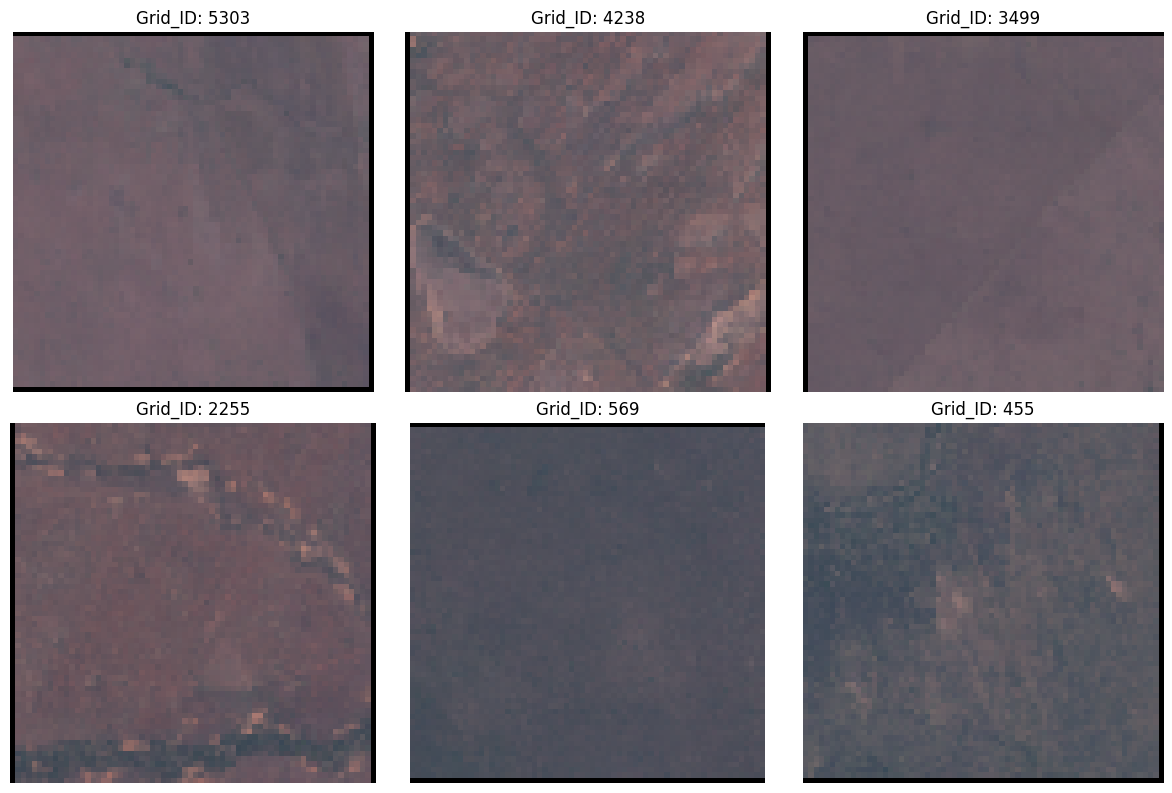

In [54]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Pick 6 random images from the dataset
sample_indices = random.sample(range(len(df)), 6)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_indices):
    img_path = df.loc[idx, "image_path"]
    if os.path.exists(img_path):  # safety check
        img = Image.open(img_path)
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"Grid_ID: {df.loc[idx, 'Grid_ID']}")
        plt.axis("off")

plt.tight_layout()
plt.show()


In [51]:
import rasterio
from PIL import Image
import numpy as np
import os

output_folder = "grid_patches_final_png"
os.makedirs(output_folder, exist_ok=True)

for idx, row in df.iterrows():
    img_path = row["image_path"]
    out_path = os.path.join(output_folder, f"grid_{row['Grid_ID']}.png")
    
    with rasterio.open(img_path) as src:
        img = src.read([4,3,2])  # RGB
        img = np.transpose(img, (1,2,0))
        img = np.clip(img/3000, 0, 1) * 255  # simple scaling
        img = Image.fromarray(img.astype(np.uint8))
        img.save(out_path)
    
    df.at[idx, "image_path"] = out_path  # update path to PNG


In [53]:
df


,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk,image_path
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,20.0,41.000000,845.377507,0.423529,472.206415,Medium,grid_patches_final_png\grid_2793.png
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,20.0,29.777358,437.198946,0.666667,442.071123,High,grid_patches_final_png\grid_2795.png
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,20.0,NaN,4689.884078,0.000000,468.843681,Medium,grid_patches_final_png\grid_2536.png
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,20.0,NaN,487.156132,0.000000,495.954250,Medium,grid_patches_final_png\grid_2797.png
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,20.0,NaN,4603.308043,0.000000,470.201273,Medium,grid_patches_final_png\grid_2538.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5089,00000000000000000f77,3959,-25.161297,31.870820,991249.696614,7.208300e+06,0.320678,POLYGON ((31.879821304251173 -25.1702966612392...,10.0,NaN,5996.506627,0.000000,218.629715,Medium,grid_patches_final_png\grid_3959.png
5090,00000000000000000f79,3961,-25.143297,31.870820,991322.058036,7.210297e+06,0.336963,POLYGON ((31.879821304251173 -25.1522952486799...,10.0,NaN,5075.473015,0.000000,220.253500,Low,grid_patches_final_png\grid_3961.png
5091,00000000000000000f7d,3965,-25.107297,31.870820,991466.635479,7.214293e+06,0.312189,POLYGON ((31.879821304251173 -25.1162968719673...,30.0,NaN,1605.434424,0.000000,190.475398,Low,grid_patches_final_png\grid_3965.png
5092,00000000000000000f7f,3967,-25.089297,31.870820,991538.851485,7.216291e+06,0.327620,POLYGON ((31.879821304251173 -25.0982955595823...,30.0,31.679961,502.629840,0.000000,183.341974,Medium,grid_patches_final_png\grid_3967.png


In [56]:
df.to_csv("improved_kruger_data.csv", index=False)


In [57]:
df = pd.read_csv('improved_kruger_data.csv')

In [60]:
df.head()

,id,Grid_ID,Lat,Lon,centroid_x,centroid_y,NDVI,geometry,landcover,Water,dist_to_water,burned_area,elevation,poaching_risk,image_path
0,00000000000000000ae9,2793,-22.709387,30.899736,900720.039864,7.483380e+06,0.371845,POLYGON ((30.907817514619648 -22.7154099138099...,20.0,41.000000,845.377507,0.423529,472.206415,Medium,grid_patches_final_png\grid_2793.png
1,00000000000000000aeb,2795,-22.699908,30.903580,901143.133100,7.484421e+06,0.349758,MULTIPOLYGON (((30.902653824487828 -22.6863321...,20.0,29.777358,437.198946,0.666667,442.071123,High,grid_patches_final_png\grid_2795.png
2,000000000000000009e8,2536,-23.071500,30.904667,900161.266125,7.443216e+06,0.275776,POLYGON ((30.89942101003105 -23.06683613503629...,20.0,NaN,4689.884078,0.000000,468.843681,Medium,grid_patches_final_png\grid_2536.png
3,00000000000000000aed,2797,-22.682878,30.905124,901351.616468,7.486305e+06,0.401846,POLYGON ((30.901592578106666 -22.6847134787732...,20.0,NaN,487.156132,0.000000,495.954250,Medium,grid_patches_final_png\grid_2797.png
4,000000000000000009ea,2538,-23.057077,30.905143,900252.857366,7.444814e+06,0.255118,POLYGON ((30.907817514619648 -23.0642988931043...,20.0,NaN,4603.308043,0.000000,470.201273,Medium,grid_patches_final_png\grid_2538.png


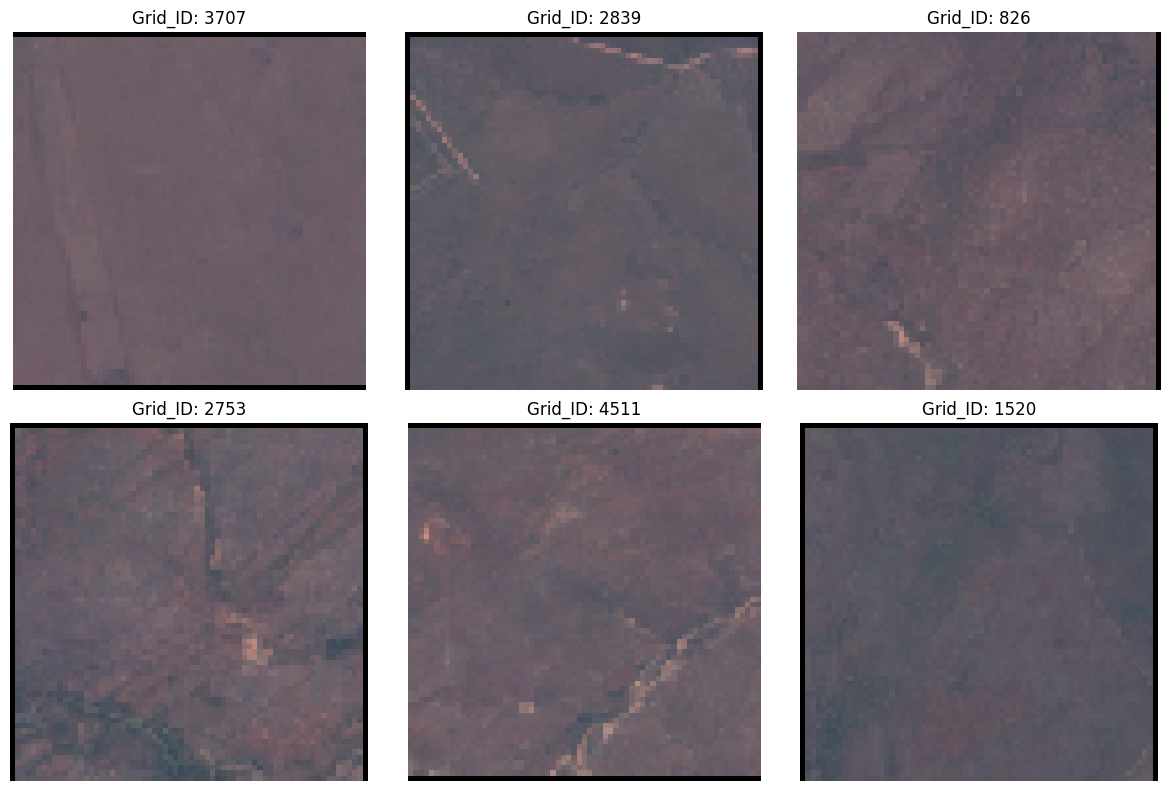

In [59]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Pick 6 random images from the dataset
sample_indices = random.sample(range(len(df)), 6)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_indices):
    img_path = df.loc[idx, "image_path"]
    if os.path.exists(img_path):  # safety check
        img = Image.open(img_path)
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"Grid_ID: {df.loc[idx, 'Grid_ID']}")
        plt.axis("off")

plt.tight_layout()
plt.show()
